In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy import stats
import seaborn as sns
from matplotlib.colors import ListedColormap
import os
import re

/Users/mikayla/.pyenv/versions/3.13.5/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("tanishksharma9905/top-popular-anime")

print("Path to dataset files:", path)

Path to dataset files: /Users/mikayla/.cache/kagglehub/datasets/tanishksharma9905/top-popular-anime/versions/1


In [4]:
file = os.path.join(path, 'popular_anime.csv')


In [5]:
print("Looking for file:", file)
print("File exists?", os.path.exists(file))

Looking for file: /Users/mikayla/.cache/kagglehub/datasets/tanishksharma9905/top-popular-anime/versions/1/popular_anime.csv
File exists? True


In [6]:
data = pd.read_csv('/Users/mikayla/.cache/kagglehub/datasets/tanishksharma9905/top-popular-anime/versions/1/popular_anime.csv')
data.head()

,id,name,genres,type,episodes,status,aired_from,aired_to,duration_per_ep,score,scored_by,rank,rating,studios,producers,image,trailer,synopsis
0,52991,Frieren: Beyond Journey's End,"Adventure, Drama, Fantasy",TV,28.0,Finished Airing,2023-09-29T00:00:00+00:00,2024-03-22T00:00:00+00:00,24 min per ep,9.30,676737.0,1.0,PG-13 - Teens 13 or older,Madhouse,"Aniplex, Dentsu, Shogakukan-Shueisha Productio...",https://cdn.myanimelist.net/images/anime/1015/...,https://www.youtube.com/watch?v=ZEkwCGJ3o7M,During their decade-long quest to defeat the D...
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy",TV,64.0,Finished Airing,2009-04-05T00:00:00+00:00,2010-07-04T00:00:00+00:00,24 min per ep,9.10,2223666.0,2.0,R - 17+ (violence & profanity),Bones,"Aniplex, Square Enix, Mainichi Broadcasting Sy...",https://cdn.myanimelist.net/images/anime/1208/...,https://www.youtube.com/watch?v=1ac3_YdSSy0,After a horrific alchemy experiment goes wrong...
2,9253,Steins;Gate,"Drama, Sci-Fi, Suspense",TV,24.0,Finished Airing,2011-04-06T00:00:00+00:00,2011-09-14T00:00:00+00:00,24 min per ep,9.07,1467570.0,3.0,PG-13 - Teens 13 or older,White Fox,"Frontier Works, Media Factory, Kadokawa Shoten...",https://cdn.myanimelist.net/images/anime/1935/...,https://www.youtube.com/watch?v=27OZc-ku6is,Eccentric scientist Rintarou Okabe has a never...
3,38524,Attack on Titan Season 3 Part 2,"Action, Drama, Suspense",TV,10.0,Finished Airing,2019-04-29T00:00:00+00:00,2019-07-01T00:00:00+00:00,23 min per ep,9.05,1700946.0,4.0,R - 17+ (violence & profanity),Wit Studio,"Production I.G, Dentsu, Mainichi Broadcasting ...",https://cdn.myanimelist.net/images/anime/1517/...,https://www.youtube.com/watch?v=hKHepjfj5Tw,Seeking to restore humanity's diminishing hope...
4,28977,Gintama Season 4,"Action, Comedy, Sci-Fi",TV,51.0,Finished Airing,2015-04-08T00:00:00+00:00,2016-03-30T00:00:00+00:00,24 min per ep,9.05,264260.0,5.0,PG-13 - Teens 13 or older,Bandai Namco Pictures,"TV Tokyo, Aniplex, Dentsu",https://cdn.myanimelist.net/images/anime/3/720...,NaN,"Gintoki, Shinpachi, and Kagura return as the f..."


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28825 entries, 0 to 28824
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               28825 non-null  int64  
 1   name             28825 non-null  object 
 2   genres           22756 non-null  object 
 3   type             28738 non-null  object 
 4   episodes         28046 non-null  float64
 5   status           28825 non-null  object 
 6   aired_from       27870 non-null  object 
 7   aired_to         10930 non-null  object 
 8   duration_per_ep  28825 non-null  object 
 9   score            18599 non-null  float64
 10  scored_by        18599 non-null  float64
 11  rank             21962 non-null  float64
 12  rating           28101 non-null  object 
 13  studios          16936 non-null  object 
 14  producers        13452 non-null  object 
 15  image            28825 non-null  object 
 16  trailer          5474 non-null   object 
 17  synopsis    

In [8]:
data[data['genres'].apply(lambda x: 'Action' in x if isinstance(x, list) else False)]

,id,name,genres,type,episodes,status,aired_from,aired_to,duration_per_ep,score,scored_by,rank,rating,studios,producers,image,trailer,synopsis


In [9]:
data = data.drop(['image', 'trailer', 'synopsis'], axis=1)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28825 entries, 0 to 28824
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               28825 non-null  int64  
 1   name             28825 non-null  object 
 2   genres           22756 non-null  object 
 3   type             28738 non-null  object 
 4   episodes         28046 non-null  float64
 5   status           28825 non-null  object 
 6   aired_from       27870 non-null  object 
 7   aired_to         10930 non-null  object 
 8   duration_per_ep  28825 non-null  object 
 9   score            18599 non-null  float64
 10  scored_by        18599 non-null  float64
 11  rank             21962 non-null  float64
 12  rating           28101 non-null  object 
 13  studios          16936 non-null  object 
 14  producers        13452 non-null  object 
dtypes: float64(4), int64(1), object(10)
memory usage: 3.3+ MB


In [11]:
def convertDuration(duration):
    if not isinstance(duration, str):
        return None
    
    # remove 'per ep'
    duration = duration.replace('per ep', '').strip()
    
    # match hours & minutes
    hr_match = re.search(r'(\d+)\s*hr', duration)
    min_match = re.search(r'(\d+)\s*min', duration)
    
    totalMinutes = 0
    if hr_match:
        totalMinutes += int(hr_match.group(1)) * 60
    if min_match:
        totalMinutes += int(min_match.group(1))
    
    # if nothing was parsed, pass None
    return int(totalMinutes) if totalMinutes > 0 else None

In [12]:
data['duration_per_ep'] = data['duration_per_ep'].apply(convertDuration)

In [13]:
data.head(10)

,id,name,genres,type,episodes,status,aired_from,aired_to,duration_per_ep,score,scored_by,rank,rating,studios,producers
0,52991,Frieren: Beyond Journey's End,"Adventure, Drama, Fantasy",TV,28.0,Finished Airing,2023-09-29T00:00:00+00:00,2024-03-22T00:00:00+00:00,24.0,9.30,676737.0,1.0,PG-13 - Teens 13 or older,Madhouse,"Aniplex, Dentsu, Shogakukan-Shueisha Productio..."
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy",TV,64.0,Finished Airing,2009-04-05T00:00:00+00:00,2010-07-04T00:00:00+00:00,24.0,9.10,2223666.0,2.0,R - 17+ (violence & profanity),Bones,"Aniplex, Square Enix, Mainichi Broadcasting Sy..."
2,9253,Steins;Gate,"Drama, Sci-Fi, Suspense",TV,24.0,Finished Airing,2011-04-06T00:00:00+00:00,2011-09-14T00:00:00+00:00,24.0,9.07,1467570.0,3.0,PG-13 - Teens 13 or older,White Fox,"Frontier Works, Media Factory, Kadokawa Shoten..."
3,38524,Attack on Titan Season 3 Part 2,"Action, Drama, Suspense",TV,10.0,Finished Airing,2019-04-29T00:00:00+00:00,2019-07-01T00:00:00+00:00,23.0,9.05,1700946.0,4.0,R - 17+ (violence & profanity),Wit Studio,"Production I.G, Dentsu, Mainichi Broadcasting ..."
4,28977,Gintama Season 4,"Action, Comedy, Sci-Fi",TV,51.0,Finished Airing,2015-04-08T00:00:00+00:00,2016-03-30T00:00:00+00:00,24.0,9.05,264260.0,5.0,PG-13 - Teens 13 or older,Bandai Namco Pictures,"TV Tokyo, Aniplex, Dentsu"
5,60022,One Piece Fan Letter,"Action, Adventure, Fantasy",TV Special,1.0,Finished Airing,2024-10-20T00:00:00+00:00,NaN,24.0,9.04,83738.0,7.0,PG-13 - Teens 13 or older,Toei Animation,NaN
6,39486,Gintama: The Very Final,"Action, Comedy, Drama, Sci-Fi",Movie,1.0,Finished Airing,2021-01-08T00:00:00+00:00,NaN,104.0,9.04,80788.0,6.0,PG-13 - Teens 13 or older,Bandai Namco Pictures,"TV Tokyo, Aniplex, Dentsu, Bandai, Warner Bros..."
7,11061,Hunter x Hunter,"Action, Adventure, Fantasy",TV,148.0,Finished Airing,2011-10-02T00:00:00+00:00,2014-09-24T00:00:00+00:00,23.0,9.03,1883243.0,8.0,PG-13 - Teens 13 or older,Madhouse,"VAP, Nippon Television Network, Shueisha"
8,9969,Gintama Season 2,"Action, Comedy, Sci-Fi",TV,51.0,Finished Airing,2011-04-04T00:00:00+00:00,2012-03-26T00:00:00+00:00,24.0,9.02,249397.0,9.0,PG-13 - Teens 13 or older,Sunrise,"TV Tokyo, Aniplex, Dentsu, Trinity Sound, Mira..."
9,15417,Gintama: Enchousen,"Action, Comedy, Sci-Fi",TV,13.0,Finished Airing,2012-10-04T00:00:00+00:00,2013-03-28T00:00:00+00:00,24.0,9.02,173888.0,10.0,PG-13 - Teens 13 or older,Sunrise,"TV Tokyo, Aniplex, Dentsu, Shueisha, Miracle Bus"


In [14]:
data.describe()

,id,episodes,duration_per_ep,score,scored_by,rank
count,28825.000000,28046.000000,27087.000000,18599.000000,1.859900e+04,21962.000000
mean,34131.945117,13.827462,21.520065,6.397697,2.989163e+04,10522.959749
std,19617.957463,46.841239,24.461345,0.889835,1.212973e+05,6386.404388
min,1.000000,1.000000,1.000000,1.890000,1.010000e+02,0.000000
25%,15979.000000,1.000000,4.000000,5.780000,3.400000e+02,4989.250000
50%,38070.000000,2.000000,15.000000,6.370000,1.544000e+03,10462.500000
75%,51060.000000,13.000000,25.000000,7.030000,1.009150e+04,16022.750000
max,61871.000000,3057.000000,169.000000,9.300000,2.943048e+06,21729.000000


In [15]:
data = data.drop_duplicates()

In [16]:
data = data.dropna()

In [17]:
data.to_csv('popularAnime.csv')

In [18]:
palette = ['#c9be9c', '#c2a2b5', '#c585a6', '#9c8dae', '#a6c7c9', '#82c0c6']
customCmap = ListedColormap(palette)

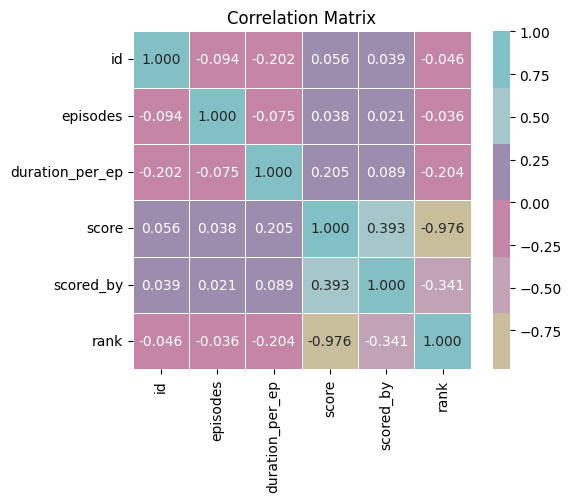

In [19]:
# correlation matrix
correlationMatrix = data.select_dtypes(include=['number', 'bool']).corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlationMatrix, annot=True, cmap=customCmap,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [20]:
data.head()

,id,name,genres,type,episodes,status,aired_from,aired_to,duration_per_ep,score,scored_by,rank,rating,studios,producers
0,52991,Frieren: Beyond Journey's End,"Adventure, Drama, Fantasy",TV,28.0,Finished Airing,2023-09-29T00:00:00+00:00,2024-03-22T00:00:00+00:00,24.0,9.30,676737.0,1.0,PG-13 - Teens 13 or older,Madhouse,"Aniplex, Dentsu, Shogakukan-Shueisha Productio..."
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy",TV,64.0,Finished Airing,2009-04-05T00:00:00+00:00,2010-07-04T00:00:00+00:00,24.0,9.10,2223666.0,2.0,R - 17+ (violence & profanity),Bones,"Aniplex, Square Enix, Mainichi Broadcasting Sy..."
2,9253,Steins;Gate,"Drama, Sci-Fi, Suspense",TV,24.0,Finished Airing,2011-04-06T00:00:00+00:00,2011-09-14T00:00:00+00:00,24.0,9.07,1467570.0,3.0,PG-13 - Teens 13 or older,White Fox,"Frontier Works, Media Factory, Kadokawa Shoten..."
3,38524,Attack on Titan Season 3 Part 2,"Action, Drama, Suspense",TV,10.0,Finished Airing,2019-04-29T00:00:00+00:00,2019-07-01T00:00:00+00:00,23.0,9.05,1700946.0,4.0,R - 17+ (violence & profanity),Wit Studio,"Production I.G, Dentsu, Mainichi Broadcasting ..."
4,28977,Gintama Season 4,"Action, Comedy, Sci-Fi",TV,51.0,Finished Airing,2015-04-08T00:00:00+00:00,2016-03-30T00:00:00+00:00,24.0,9.05,264260.0,5.0,PG-13 - Teens 13 or older,Bandai Namco Pictures,"TV Tokyo, Aniplex, Dentsu"


/var/folders/xg/9_zxrtsn0ll10hckyb7z5l780000gn/T/ipykernel_91622/1204251600.py:2: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(y='score', x='rating', hue='status', data=data, palette=palette)


<Axes: xlabel='rating', ylabel='score'>

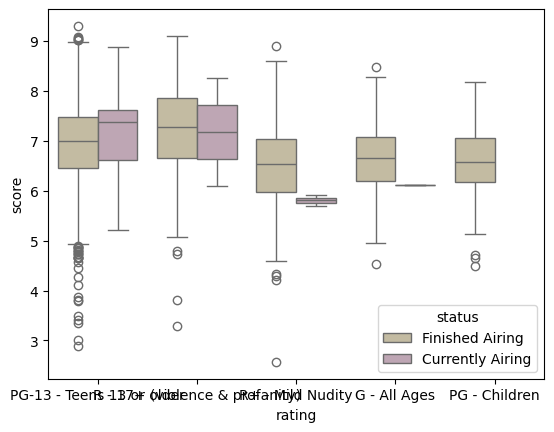

In [21]:
# def wanted to do some box plots
sns.boxplot(y='score', x='rating', hue='status', data=data, palette=palette)